In [1]:
!pipx inject notebook numpy pandas matplotlib seaborn

  injected package numpy into venv notebook
done! ✨ 🌟 ✨
  injected package pandas into venv notebook
done! ✨ 🌟 ✨
  injected package matplotlib into venv notebook
done! ✨ 🌟 ✨
  injected package seaborn into venv notebook
done! ✨ 🌟 ✨


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Iris DataSet** 
Iris dataset has the follwing features
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

we have to use them to classify them to classes such as:
- Iris-setosa
- Iris-versicolor
- Iris-virginica


# 1. Loading the dataset
```ascii
Parameters
    ----------
    filepath : str
        Path to dataset.

    column_names : list, optional
        List of column names.

    separator : str
        Delimiter used in the file.

    Returns
    -------
    DataFrame
```

In [3]:
def load_dataset(filepath,column_names=None,seperator=","):
    df=pd.read_csv(filepath,names=column_names,sep=seperator)
    df.columns = df.columns.str.strip()
    return df

# 2. Dataset Information

Displays basic information about the data
- shape
- columns
- info
- head


In [4]:
def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-"*50)

    print("\n Shape: ",df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())

    print("\nData Types: ")
    print(df.dtypes)

    print("\nMemory information")
    df.info()

    print("First 5 elements")
    print(df.head())

# 3.Missing Values and duplicate values


In [5]:
def missing_values(df):
    missing=df.isnull().sum()
    percent=(missing/len(df) )*100

    result=pd.DataFrame(
    {"missing":missing,
    "percent":percent
    })

    print(result)

    if (missing.sum() ==0):
        print("There is no missing value!")
    else:
        print("Missing Values detected")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ",duplicates);

    if(duplicates ==0):
        print("No duplicates detected!")
    else:
        print("Duplicates are detected")

    return duplicates

In [6]:
column_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df = load_dataset(
    "iris/iris.data",
    column_names
)

dataset_info(df)

missing_values(df)

_=duplicate_info(df)

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (150, 5)

Columns: 
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

Data Types: 
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
class               str
dtype: object

Memory information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
First 5 elements
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1          

## Observation:
- The dataset contains 150 entries with the 5 column
- The first four are the numerical column and the other one is the class to be predicted
- No missing data is found
- Three duplicate values is detected!

# 4. EDA for a dataset

In [7]:
def summary_statistics(df):
    print("\nSummary statsitics")
    print(df.describe())

def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    plt.show()

    return counts


    

In [8]:
summary_statistics(df)



Summary statsitics
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


## Observation (summary):
- petal length has highest deviation from its standaed deviation
- Overview of each numerical stat is given


Class Distribution


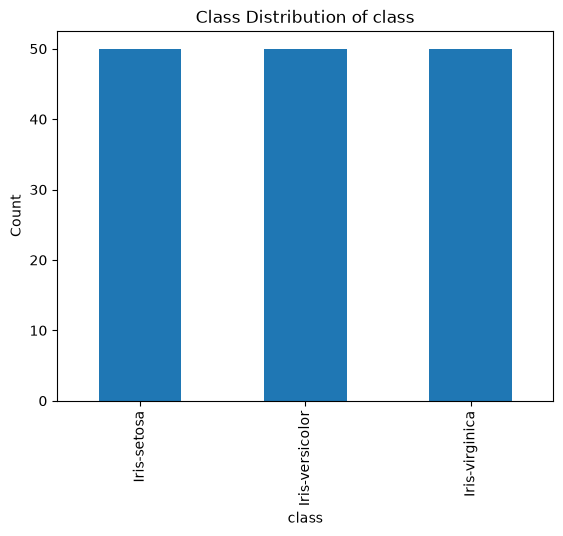

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [9]:
class_distribution(df,"class")

## Observation - Class Distribution

- Each Iris species has 50 samples
- The dataset is balanced across in all the three classes
- A balanced dataset helps prevent bias toward any particular class during model training.

In [10]:
def plot_histogram(df,bins=10):
    numeric_df=df.select_dtypes("number")

    numeric_df.hist(bins=bins)
    plt.suptitle("Histogram of numerical features")
    plt.tight_layout()
    plt.show()

def plot_boxplot(df):
    numeric_df = df.select_dtypes("number")

    for col in numeric_df.columns:
        plt.boxplot(numeric_df[col])
        plt.title("BoxPlot of "+str(col))
        plt.show()
def plot_heatmap(df):
    numeric_df = df.select_dtypes("number")
    corr = numeric_df.corr()
    sns.heatmap(corr,annot=True)
    plt.title("Heatmap !")
    plt.show()

def plot_scatterplot(df,target_column=None):

    if (target_column is not None):
        sns.pairplot(df,hue=target_column)
    else:
        sns.pairplot(df)
    plt.suptitle("Pairplot")
    plt.tight_layout()
    plt.show()

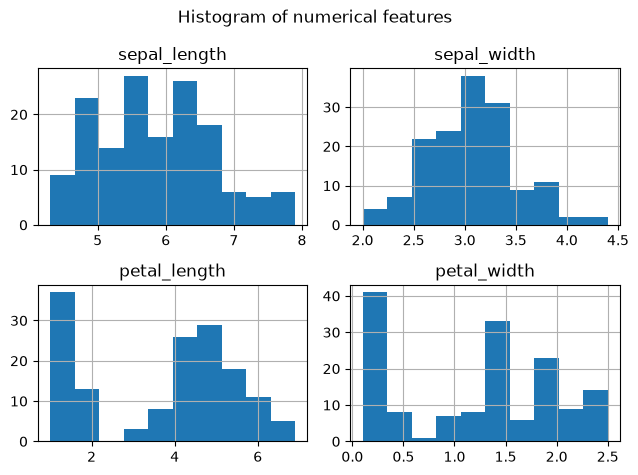

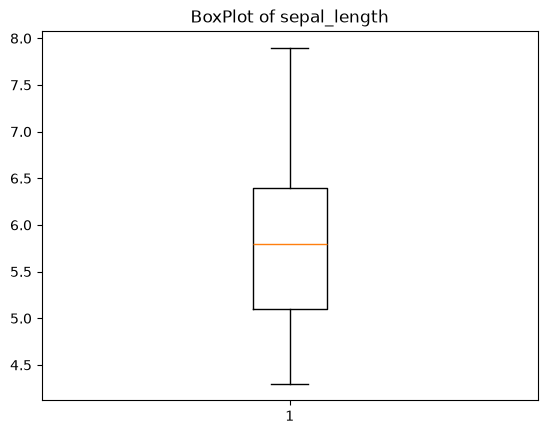

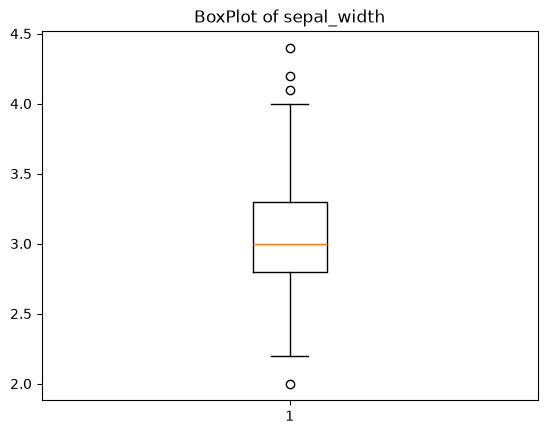

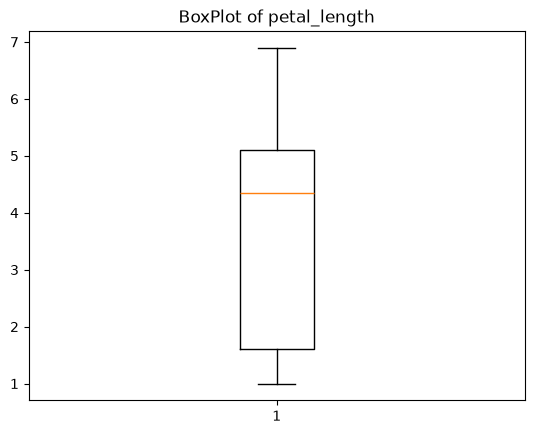

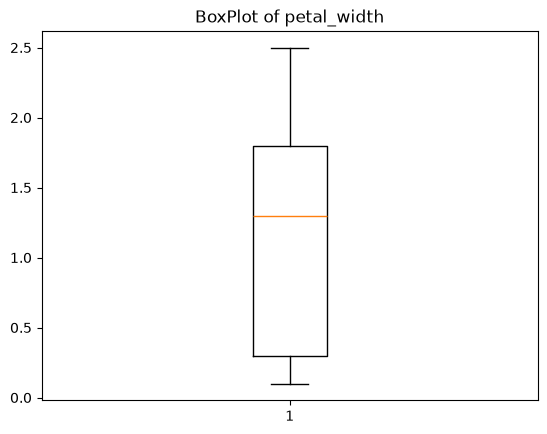

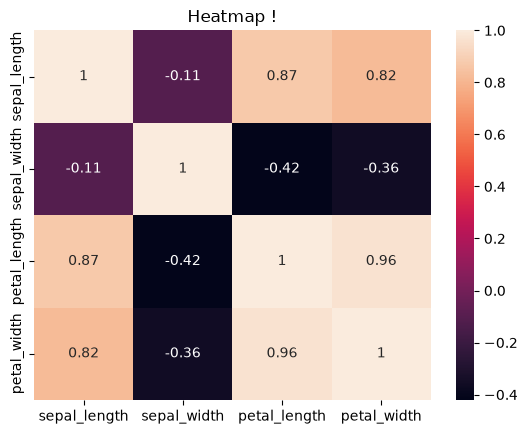

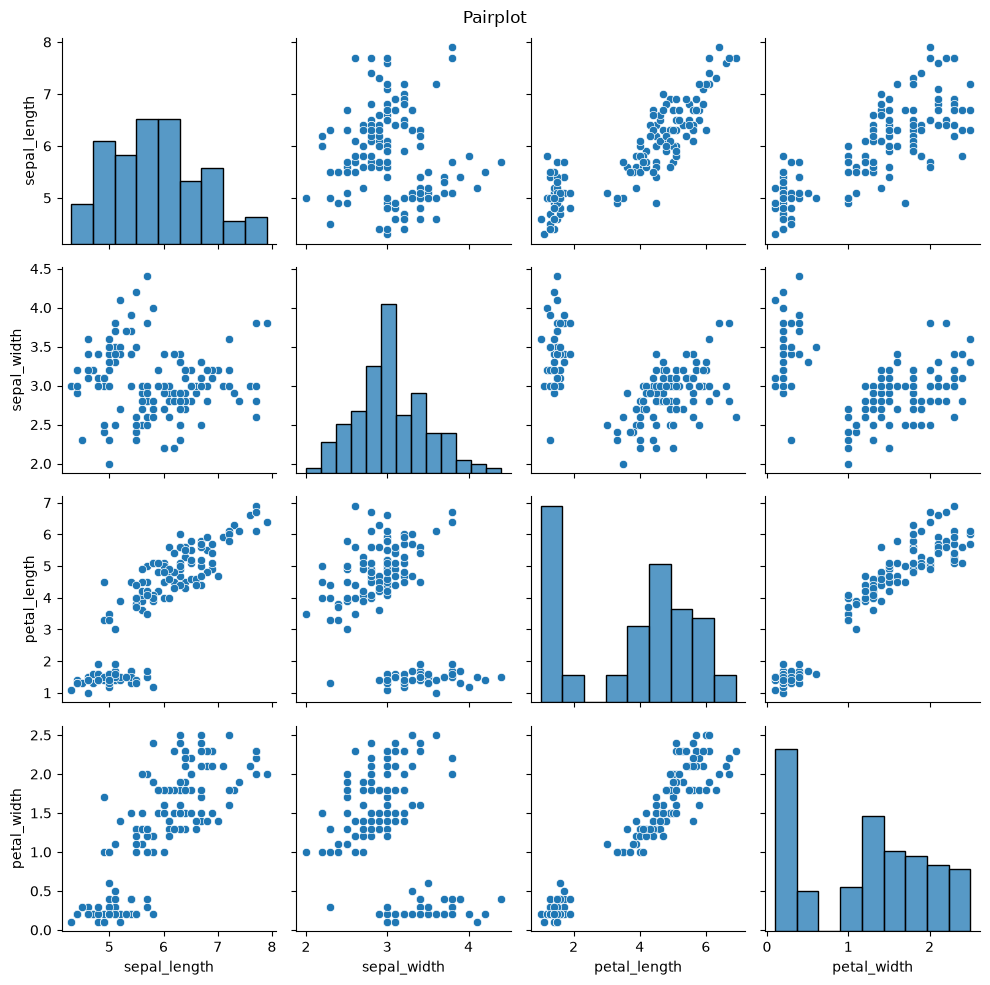

In [11]:
plot_histogram(df)
plot_boxplot(df)
plot_heatmap(df)
plot_scatterplot(df)

## Observation - Histogram

- Sepal_length and sepal_width are roughly unimodal, centered around their respective means.
- Petal_length and petal_width are clearly **bimodal**, with a distinct low cluster (petal_length ~1–2, petal_width ~0–0.3) separated from a second, wider cluster (petal_length ~3–7, petal_width ~1–2.5).
- This bimodal split strongly suggests one species (setosa) is separable from the other two using petal measurements alone.


## Observation - Box Plot

- Sepal_length, petal_length, and petal_width show **no outliers**.
- Sepal_width is the only feature with outliers, with points above **4.0** and below **2.0**.
- Petal_length has the **widest interquartile range (1.6–5.1)**, consistent with it spanning two distinct clusters rather than one.


## Observation - Correlation Heatmap

- Petal length and petal width show a very strong positive correlation (approximately 0.96).
- Sepal length is also strongly positively correlated with petal length and petal width.
- Sepal width shows weak to moderate negative correlations with the petal measurements.
- These relationships indicate that petal measurements are the most informative features for distinguishing Iris species.

## Observation - Pair Plot

- The pair plot displays pairwise relationships between all numerical features in the dataset.
- The diagonal plots show the distribution of each individual feature using histograms.
- Several scatter plots exhibit natural clustering of data points, indicating the presence of distinct groups within the dataset.
- Petal length and petal width show the clearest clustering pattern and a strong positive linear relationship.
- Sepal length also exhibits a positive relationship with both petal length and petal width.
- Sepal width shows comparatively weaker relationships and greater overlap among the observations.
- The pair plot suggests that petal-related features are more effective in distinguishing different flower samples than sepal-related features.

# **2.Loan approval Dataset**
Features:
Basic deails of the loaner(like education,income,loan term,cibil score,etc)

Prediction:
- Loan amount

In [12]:
'''
Loading the dataset
'''
df = load_dataset("LoanAmount/loan_approval_dataset.csv")

In [13]:
'''
basic data analysis
'''
dataset_info(df)

missing_values(df)

duplicate_info(df)

summary_statistics(df)

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (4269, 13)

Columns: 
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Data Types: 
loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object

Memory information
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column               

## Observation - Dataset Information

- The dataset contains **4,269 records** and **13 features**.
- There are **10 numerical features** and **3 categorical features** (education, self_employed, and loan_status).
- All columns have valid data types and are suitable for further analysis.
- The dataset contains applicant information, financial details, and loan approval status.

## Observation - Missing Values

- No missing values are present in any of the dataset columns.
- Therefore, no data cleaning or imputation is required before analysis.

## Observation - Duplicate Values

- No duplicate records were found in the dataset.
- Every record represents a unique loan application.

## Observation - Summary Statistics

- Applicant income varies in a wide range, this shows clients are from different economic background
- Loan amounts also cover a broad range, suggesting loans of varying sizes.
- CIBIL scores range from **300 to 900**, representing applicants with different creditworthiness.
- Loan terms vary between **2 and 20 years**.
- An unusual negative value is observed in the residential asset column, which may indicate a data entry error or special case that should be examined during preprocessing.

## EDA 


Class Distribution


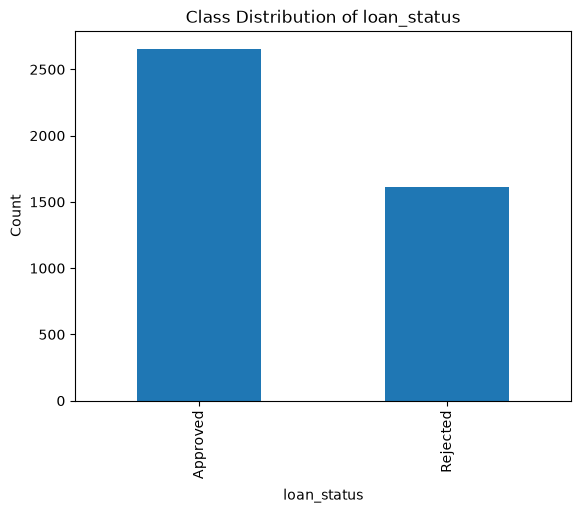


Class Distribution


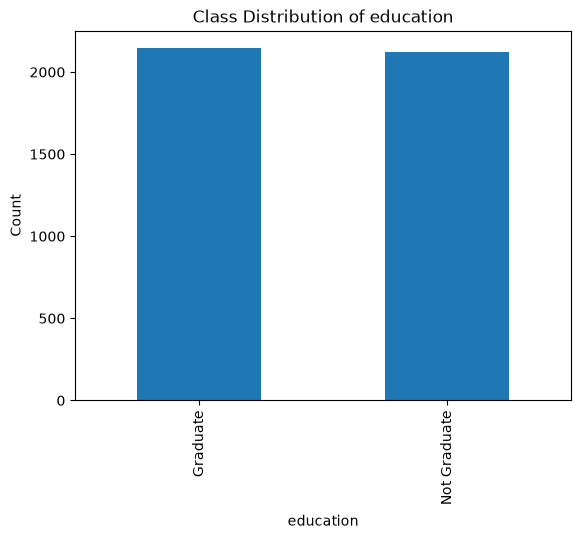


Class Distribution


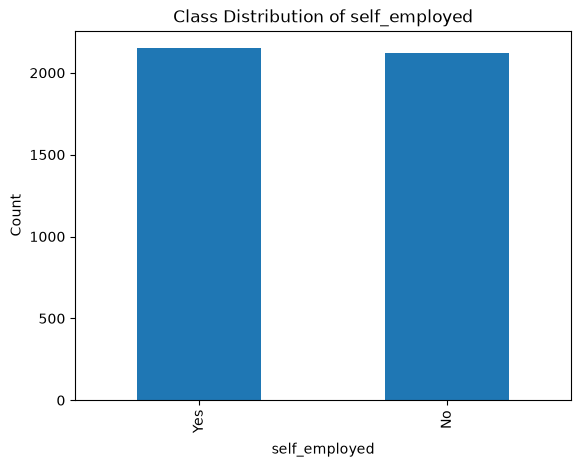

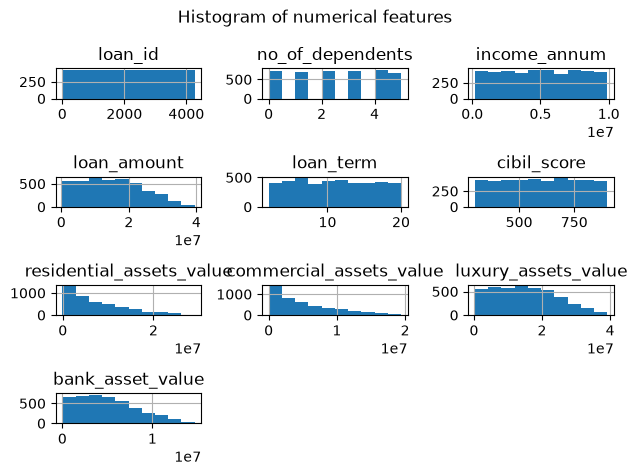

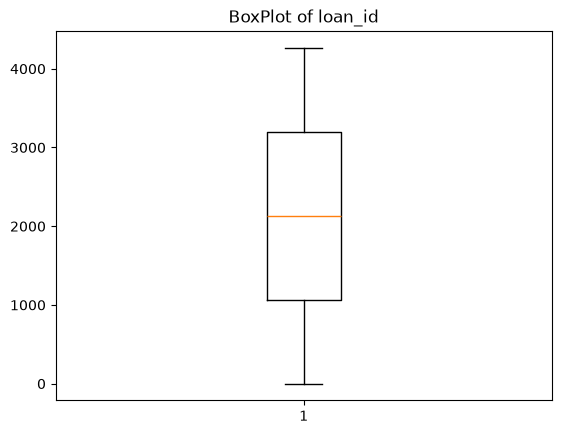

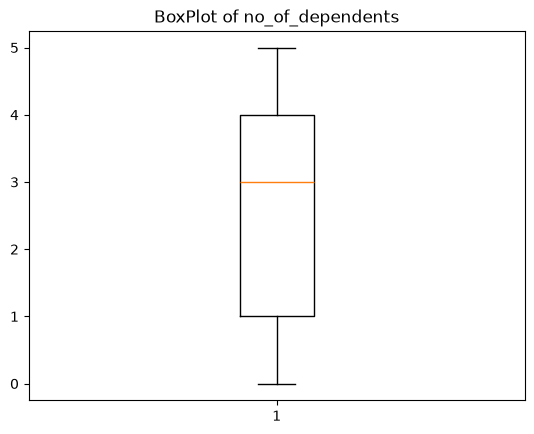

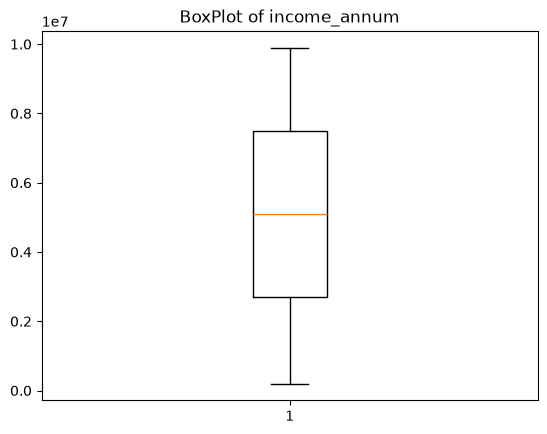

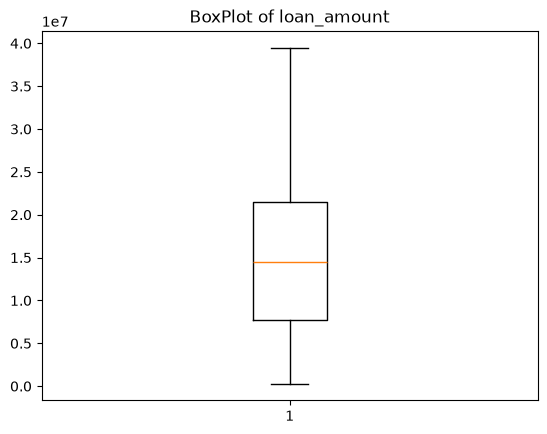

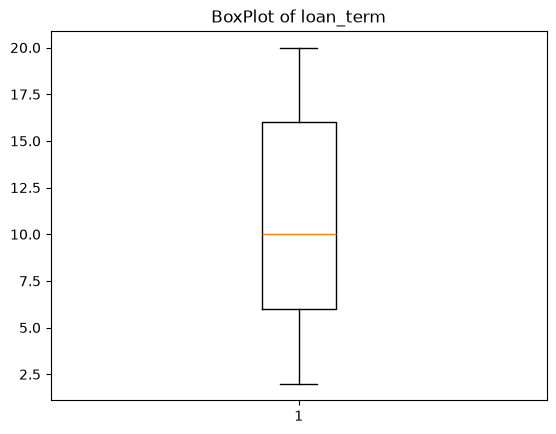

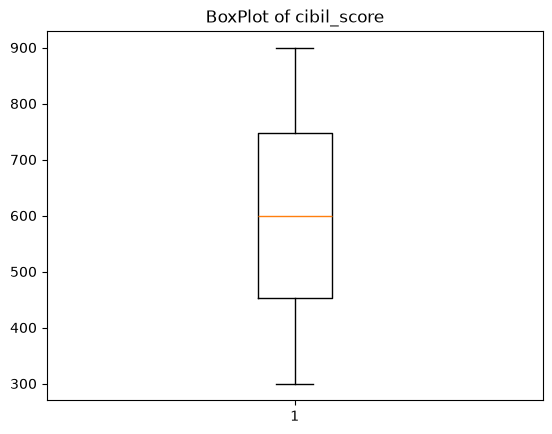

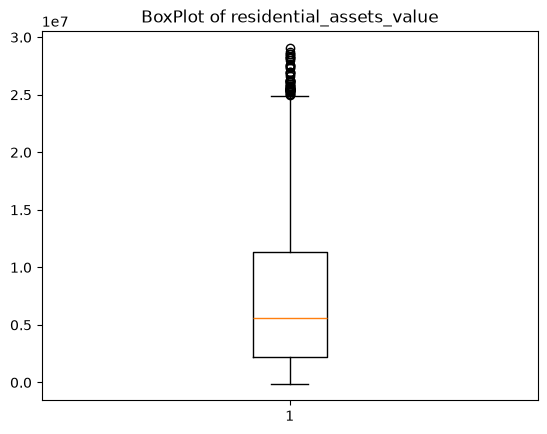

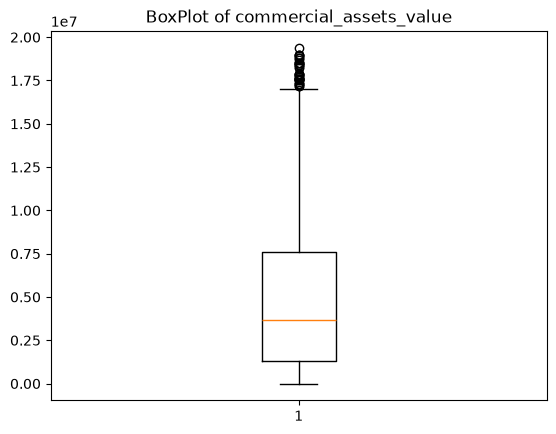

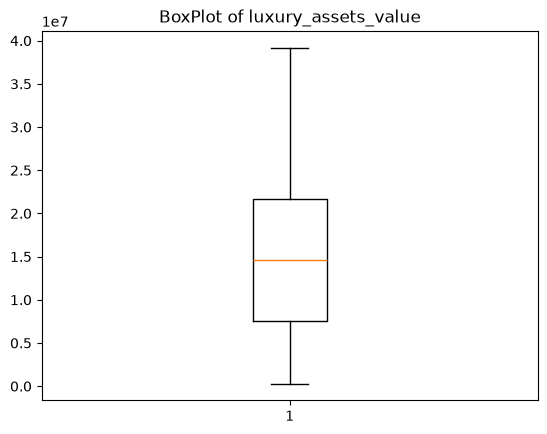

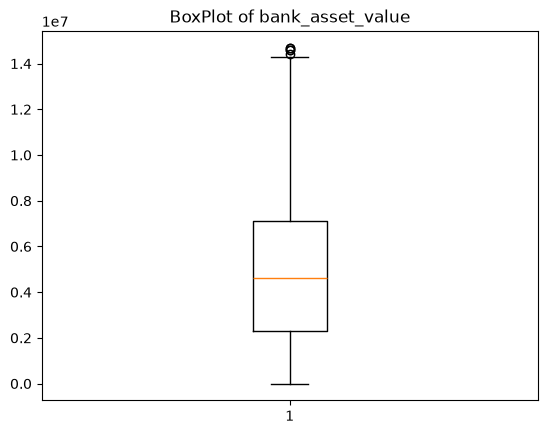

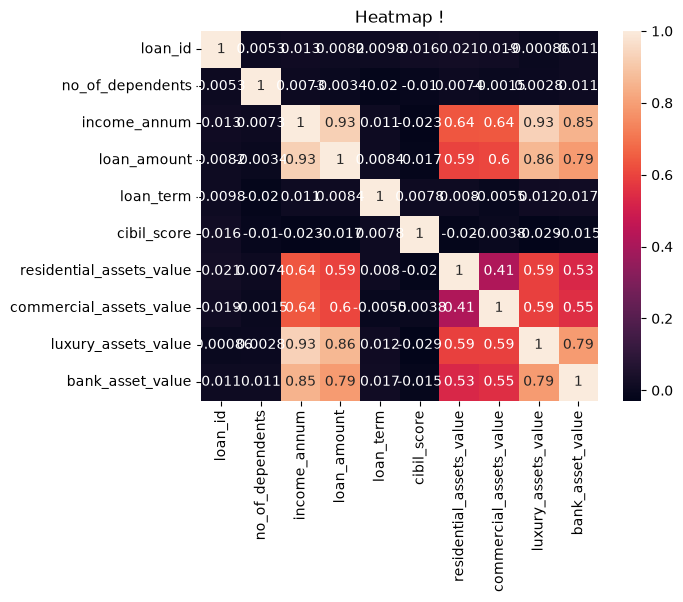

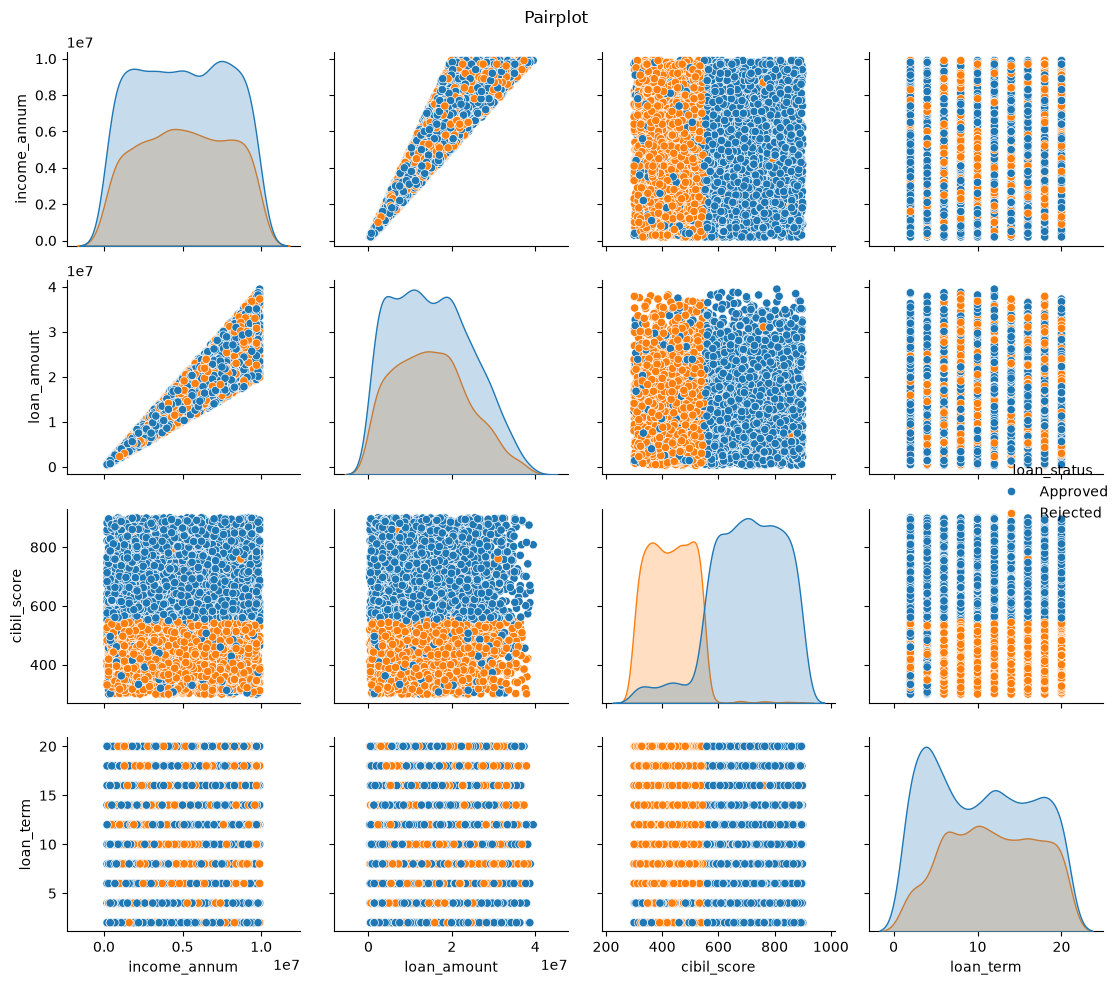

In [14]:
class_distribution(df, "loan_status")
class_distribution(df, "education")
class_distribution(df, "self_employed")
plot_histogram(df)
plot_boxplot(df)
plot_heatmap(df)
important_features = [
    "income_annum",
    "loan_amount",
    "cibil_score",
    "loan_term",
    "loan_status"
]

plot_scatterplot(df[important_features], "loan_status")

## Observation - Loan Status Distribution

- The dataset contains both approved and rejected loan applications.
- Understanding this distribution helps identify whether the dataset is balanced or imbalanced before model training.
- We can see Aquired is higher in distribution!

## Observation - Education Distribution

- Applicants are divided into Graduate and Not Graduate categories.
- Both graduate and not graduate are equal and hence balanced

## Observation - Self Employed Distribution

- Applicants are categorized as self-employed or non-self-employed.
- It is balanced!

## Observation - Histogram

- Income_annum, loan_term, and cibil_score are all fairly **uniform**, with no distinct peak.
- Loan_amount and all four asset-value columns are **right-skewed**, concentrated at lower values with a long tail toward the maximum.

## Observation - Box Plot

- Residential_assets_value, commercial_assets_value, and bank_asset_value all show **upper outliers**.
- Income_annum, loan_amount, loan_term, and cibil_score show **no outliers**.
- We can see ( residential_asset_value , commercial_asset_value and bank asset value having outliers

## Observation - Correlation Heatmap

- Income_annum and loan_amount show a **strong positive correlation (0.93)**.
- Income also correlates strongly with luxury_assets_value (**0.93**) and bank_asset_value (**0.85**).
- Cibil_score shows **very poor correlation** with every other feature (**-0.02 to 0.03**), including loan_amount.
- Asset-value features show moderate correlation with one another (**0.41–0.79**).


## Observation - Pair Plot

- Cibil_score is the only feature where approved and rejected applications form **visibly separated distributions** — rejected applications skew lower, approved skew higher.
- Income_annum, loan_amount, and loan_term show **heavy overlap** between the two classes with no clear separation.
- This suggests cibil_score, despite its poor correlation with other numerical features, is the **strongest visual predictor of loan_status**.

In [18]:
def perform_eda(
    filepath,
    target_column=None,
    categorical_columns=None,
    pairplot_columns=None,
    column_names=None,
    separator=","):

    df=load_dataset(filepath,column_names=column_names,seperator=separator)
    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)

    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df,col)

    plot_histogram(df)

    plot_boxplot(df)

    plot_heatmap(df)

    if pairplot_columns is not None:
        if tatget_column is not None:
            plot_scatterplot(df[pairplot_columns],target_column)
        else:
            plot_scatterplot(df[pairplot_columns])

    return df
    


In [16]:
# df=perform_eda("emailSpam/emails.csv")

# **3. Predicting Diabetes**
- Classification of whether a person has diabetes


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (100000, 9)

Columns: 
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data Types: 
gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Memory information
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart

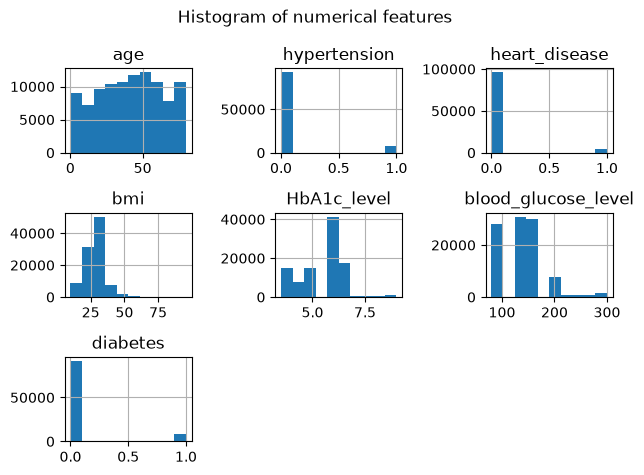

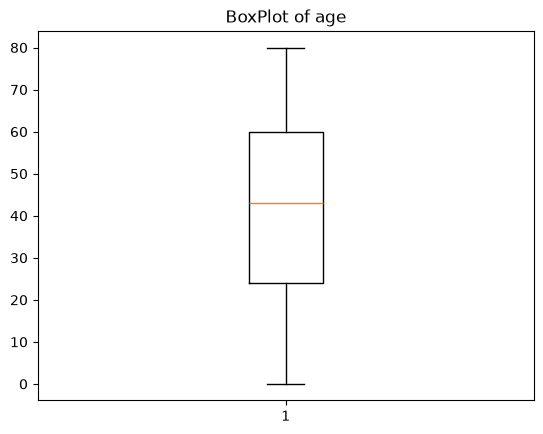

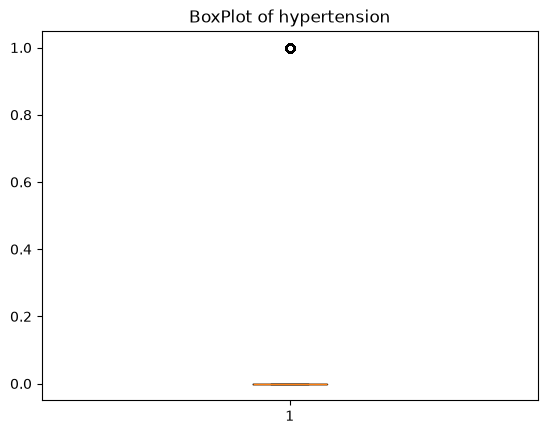

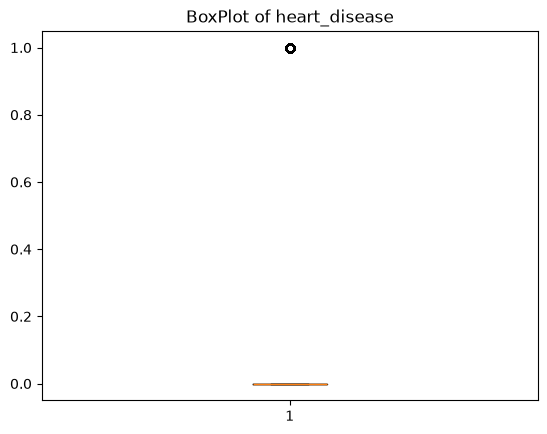

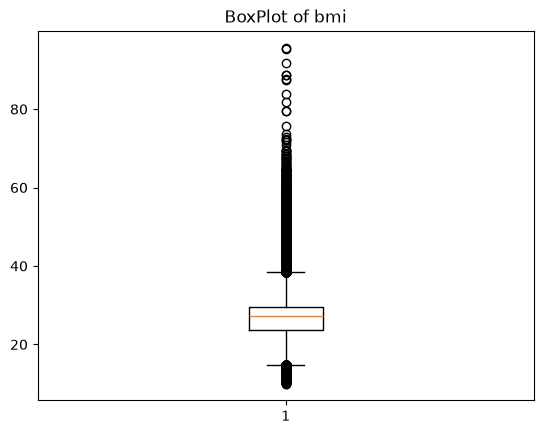

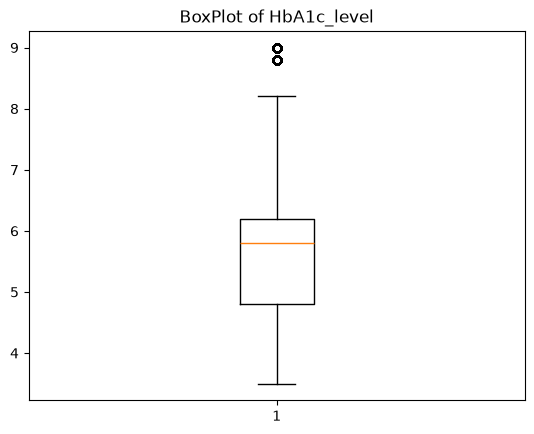

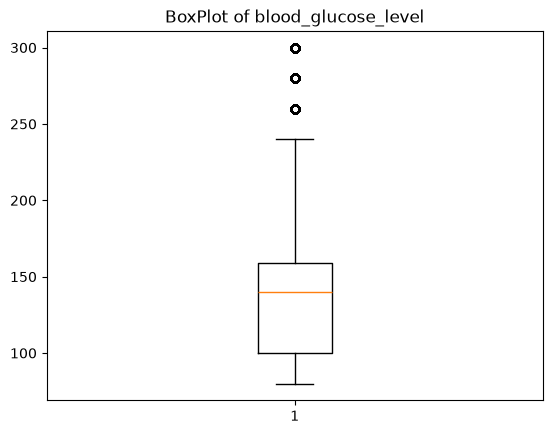

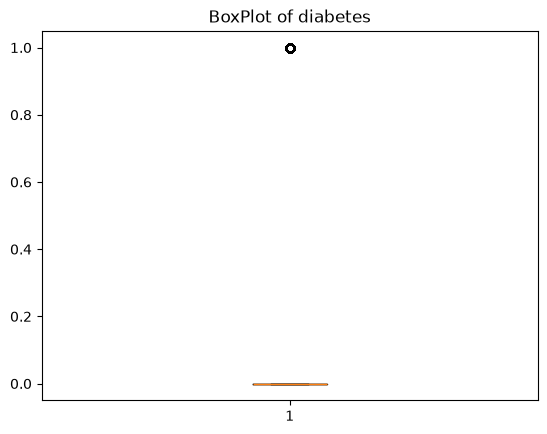

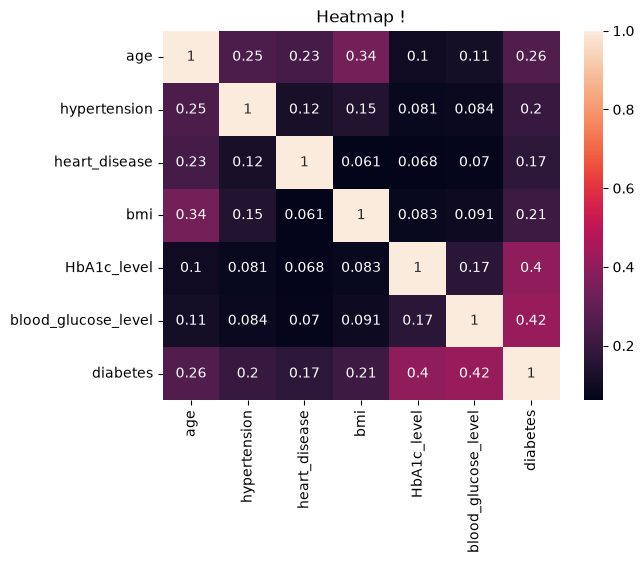

In [19]:
df=perform_eda("Diabetes_Prediction/diabetes_prediction_dataset.csv")

## Observation - Dataset Information

- The dataset contains **100,000 records** and **9 features**.
- There are **8 input features** and **1 target feature** (`diabetes`), along with categorical attributes such as gender and smoking history.
- The dataset consists of both numerical and categorical variables describing patient health and lifestyle.
- The dataset is suitable for a supervised binary classification task.

## Observation - Missing Values

- No missing values are present in any of the dataset columns.
- Since the dataset is complete, no missing value treatment is required.

## Observation - Duplicate Values

- A total of **3,854 duplicate records** were detected in the dataset.
- Duplicate records may introduce redundancy and bias during model training.
- Duplicates need to be dealt with in preprocessing stage

## Observation - Summary Statistics

- Patient ages range from **0.08 years to 80 years**, indicating that the dataset includes individuals from infancy to old age.
- BMI values range from **10.01 to 95.69**, showing considerable variation in body mass among patients.
- HbA1c levels vary between **3.5 and 9.0**, representing different levels of long-term blood glucose control.
- Blood glucose levels range from **80 to 300 mg/dL**, covering both normal and diabetic conditions.
- The diabetes target variable is binary, with values **0 (Non-Diabetic)** and **1 (Diabetic)**.

## Observation - Histogram

- Age is distributed across a wide range, with a higher concentration of patients between approximately 20 and 60 years.
- Hypertension and heart disease are highly imbalanced, as most patients belong to class 0 (absence of the condition).
- BMI values are concentrated around the mid-25s, with relatively fewer patients having very low or very high BMI.
- HbA1c levels show a prominent peak around 6.0, with smaller concentrations between approximately 3.5 and 5.0.
- Very high HbA1c values (above about 7) occur much less frequently.
- Blood glucose levels are mainly concentrated between 80 and 160, with fewer observations at higher levels.
- The diabetes target variable is highly imbalanced, with non-diabetic patients (0) significantly outnumbering diabetic patients (1).

## Observation - Box Plot

- Age does not exhibit significant outliers and is spread across the entire age range.
- BMI contains numerous upper outliers, indicating the presence of patients with unusually high BMI values.
- HbA1c level shows a few high-value outliers above the upper whisker.
- Blood glucose level also contains several upper outliers, with values extending close to 300.
- Binary features such as hypertension, heart disease, and diabetes show limited variation due to their binary nature.

## Observation - Heatmap

- Most numerical features exhibit weak to moderate positive correlations.
- Blood glucose level has the highest correlation with diabetes (0.42).
- HbA1c level also shows a moderate positive correlation with diabetes (0.40).
- Age and BMI have weak positive correlations with diabetes (0.26 and 0.21 respectively).
- No pair of features exhibits very strong multicollinearity, indicating that the numerical features provide distinct information.

In [22]:
def perform_eda(
    filepath,
    target_column=None,
    categorical_columns=None,
    pairplot_columns=None,
    column_names=None,
    separator=",",

    show_histogram=True,
    show_boxplot=True,
    show_heatmap=True,
    show_pairplot=True
):
    # -------------------------
    # Load Dataset
    # -------------------------
    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    # -------------------------
    # Basic Information
    # -------------------------
    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)

    # -------------------------
    # Class Distribution
    # -------------------------
    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)

    # -------------------------
    # Visualizations
    # -------------------------

    if show_histogram:
        plot_histogram(df)

    if show_boxplot:
        plot_boxplot(df)

    if show_heatmap:
        plot_heatmap(df)

    if show_pairplot:

        if pairplot_columns is not None:

            if target_column is not None:
                plot_scatterplot(
                    df[pairplot_columns + [target_column]],
                    target_column
                )

            else:
                plot_scatterplot(
                    df[pairplot_columns]
                )

        else:
            print("\nPairplot skipped (No columns specified).")

    return df

# **4. handwritten Character recognition**

In [23]:
from sklearn.datasets import load_digits
import pandas as pd 

digits = load_digits()
df= pd.DataFrame(digits.data)
df["target"]=digits.target

df.to_csv("digits.csv",index=False)


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (1797, 65)

Columns: 
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', 'target']

Data Types: 
0         float64
1         float64
2         float64
3         float64
4         float64
           ...   
60        float64
61        float64
62        float64
63        float64
target      int64
Length: 65, dtype: object

Memory information
<class 'pandas.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   

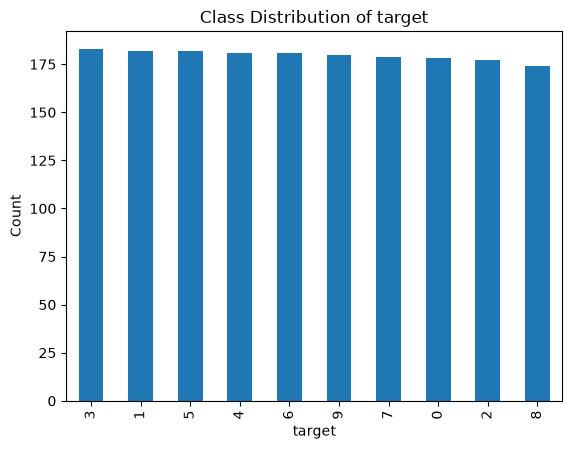

In [25]:
df = perform_eda(
    "digits.csv",
    categorical_columns=["target"],

    show_histogram=False,
    show_boxplot=False,
    show_heatmap=False,
    show_pairplot=False
)

# **5. Classification Email Spam**
- d


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (5172, 3002)

Columns: 
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec'

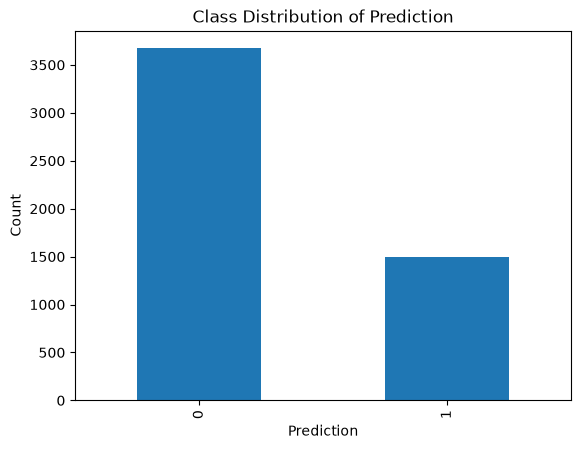

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,Email 5168,2,2,2,3,0,0,32,0,0,...,0,0,0,0,0,0,0,0,0,0
5168,Email 5169,35,27,11,2,6,5,151,4,3,...,0,0,0,0,0,0,0,1,0,0
5169,Email 5170,0,0,1,1,0,0,11,0,0,...,0,0,0,0,0,0,0,0,0,1
5170,Email 5171,2,7,1,0,2,1,28,2,0,...,0,0,0,0,0,0,0,1,0,1


In [27]:
perform_eda(
    "emailSpam/emails.csv",
    categorical_columns=["Prediction"],

    show_histogram=False,
    show_boxplot=False,
    show_heatmap=False,
    show_pairplot=False
)